In [2]:
import polars as pl
import matplotlib.pyplot as plt

In [5]:
# 1. Define Binance public trade data columns
columns = [
    "trade_id",        # The exchange's unique identifier for the transaction
    "price",           # Execution price in USDT
    "qty",             # Amount of BTC traded
    "quote_qty",       # Total value of the trade in USDT (price * qty)
    "time",            # Unix timestamp (recorded in microseconds for this specific dataset)
    "is_buyer_maker",  # True = seller hit the bid (sell pressure). False = buyer lifted the ask (buy pressure). Crucial for OFI.
    "is_best_match"    # Legacy routing field (almost always True, can be safely ignored)
]

file_path = "data/BTCUSDT-trades-2026-05.csv"

In [6]:
# --- Inspect CSV Content & Format ---
df_sample = pl.read_csv(
    file_path, 
    has_header=False, 
    new_columns=columns, 
    n_rows=5
)

print("--- Data Schema & First 5 Rows ---")
print(df_sample.glimpse())
print(df_sample)


--- Data Schema & First 5 Rows ---
Rows: 5
Columns: 7
$ trade_id        <i64> 6264713814, 6264713815, 6264713816, 6264713817, 6264713818
$ price           <f64> 76346.58, 76346.58, 76346.58, 76346.58, 76346.57
$ qty             <f64> 6e-05, 6e-05, 0.00025, 0.0017, 0.46276
$ quote_qty       <f64> 4.5807948, 4.5807948, 19.086645, 129.789186, 35330.1387332
$ time            <i64> 1777593600365107, 1777593600393777, 1777593600427352, 1777593600442008, 1777593600599768
$ is_buyer_maker <bool> False, False, False, False, True
$ is_best_match  <bool> True, True, True, True, True

None
shape: (5, 7)
┌────────────┬──────────┬─────────┬──────────────┬────────────────┬────────────────┬───────────────┐
│ trade_id   ┆ price    ┆ qty     ┆ quote_qty    ┆ time           ┆ is_buyer_maker ┆ is_best_match │
│ ---        ┆ ---      ┆ ---     ┆ ---          ┆ ---            ┆ ---            ┆ ---           │
│ i64        ┆ f64      ┆ f64     ┆ f64          ┆ i64            ┆ bool           ┆ bool         

In [7]:
df_lazy = pl.scan_csv(
    file_path, 
    has_header=False, 
    new_columns=columns
)

# Aggregate into 5-minute bars for memory-safe plotting
time_series_data = (
    df_lazy
    # select time and price columns for aggregation
    .select([
        # select time in microseconds and truncate to 5-minute intervals
        pl.col("time").cast(pl.Datetime("us")).dt.truncate("5m").alias("timestamp"),
        pl.col("price")
    ])
    .group_by("timestamp")
    # Select closing price for each 5-minute interval
    .agg(pl.col("price").last().alias("close_price"))
    .sort("timestamp")
    .collect()
)

In [22]:
row_count = df_lazy.select(pl.len()).collect()
print(row_count)

shape: (1, 1)
┌──────────┐
│ len      │
│ ---      │
│ u32      │
╞══════════╡
│ 72566188 │
└──────────┘


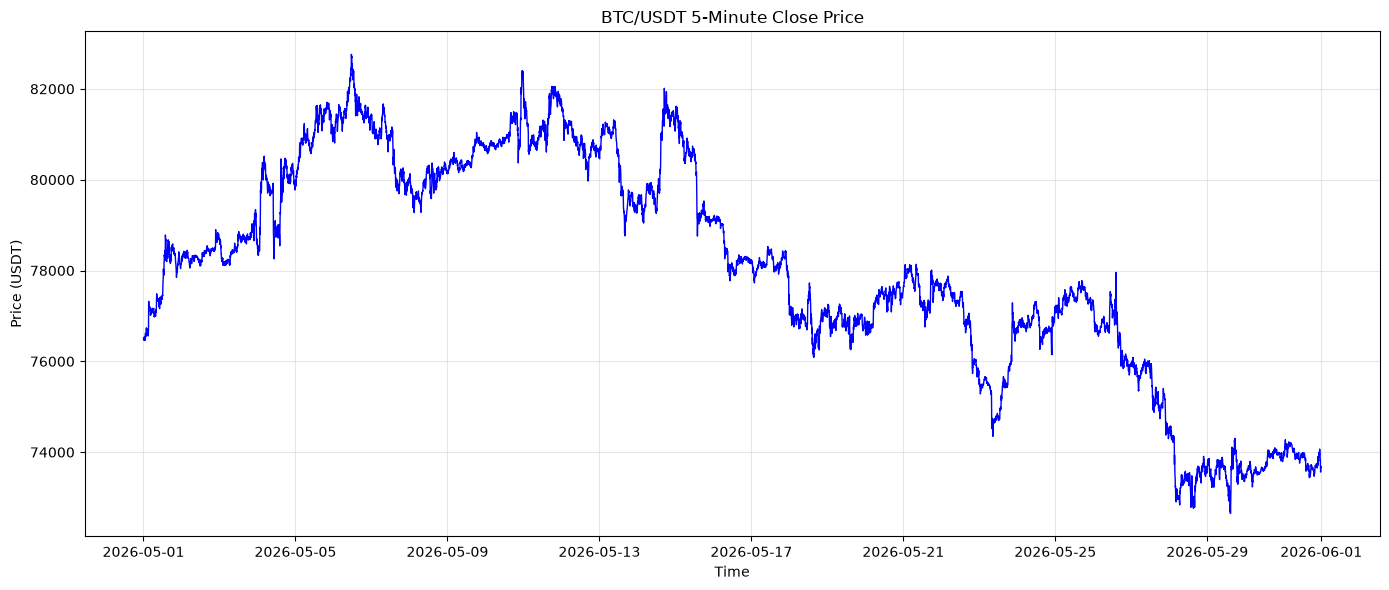

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(time_series_data["timestamp"].to_list(), time_series_data["close_price"], color="blue", linewidth=1)
plt.title("BTC/USDT 5-Minute Close Price")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()